# ESM2 Phosphorylation Prediction (Clean Pipeline)

This notebook builds a clean, reproducible protein-level classifier to predict whether a protein is phosphorylated, using **ESM2** (1280-dim) pooled embeddings.

## What this notebook does
- Loads UniProt data and defines binary labels using PTM text matching (phospho/phosphorylation).
- Loads precomputed ESM2 embeddings (max pool and attention pool, 1280-dim).
- Trains and compares Logistic Regression and MLP models.
- Evaluates ROC-AUC, PR-AUC, precision, recall, F1, and confusion matrices.
- Saves clean plots and summary tables to `results_phosphorylation_ESM2/`.
- Generates a self-contained HTML interpretation report.

In [1]:
from pathlib import Path
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 140

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
PROJECT_DIR = Path.cwd()
RESULTS_DIR = PROJECT_DIR / "results_phosphorylation_ESM2"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Locate UniProt TSV (local all_uniref)
candidate_data_dirs = [
    (PROJECT_DIR / ".." / "all_uniref").resolve(),
    (PROJECT_DIR / ".." / ".." / "all_uniref").resolve(),
]
DATA_DIR = next((p for p in candidate_data_dirs if p.exists()), candidate_data_dirs[0])
UNIPROT_FILE = DATA_DIR / "uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv"

# Locate ESM2 pooled embeddings (NFS or local extracted cache)
candidate_embed_files = [
    DATA_DIR / "esm2_embedding_cache" / "pooled_embeddings.npz",
    Path("/nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz"),
]
EMBED_FILE = next((p for p in candidate_embed_files if p.exists()), candidate_embed_files[0])

print(f"Project directory : {PROJECT_DIR}")
print(f"Data directory    : {DATA_DIR}")
print(f"Results directory : {RESULTS_DIR}")
print(f"UniProt file      : {UNIPROT_FILE}  (exists: {UNIPROT_FILE.exists()})")
print(f"Embedding file    : {EMBED_FILE}  (exists: {EMBED_FILE.exists()})")

Project directory : /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation
Data directory    : /home/saishyam/Protein_dynamics/all_uniref
Results directory : /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2
UniProt file      : /home/saishyam/Protein_dynamics/all_uniref/uniprotkb_AND_reviewed_true_AND_model_o_2026_01_16.tsv  (exists: True)
Embedding file    : /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz  (exists: True)


In [3]:
all_uniref = pd.read_csv(UNIPROT_FILE, sep="\t")
print(f"Loaded {len(all_uniref):,} proteins")
all_uniref.head()

Loaded 18,459 proteins


,Entry,Reviewed,Entry Name,Protein names,Gene Names,Organism,Length,Sequence,Zinc finger,Glycosylation,...,Beta strand,Helix,Turn,Intramembrane,Subcellular location [CC],Topological domain,Transmembrane,Lipidation,DNA binding,Motif
0,A0A087X1C5,reviewed,CP2D7_HUMAN,Cytochrome P450 2D7 (EC 1.14.14.1),CYP2D7,Homo sapiens (Human),515,MGLEALVPLAMIVAIFLLLVDLMHRHQRWAARYPPGPLPLPGLGNL...,NaN,"CARBOHYD 416; /note=""N-linked (GlcNAc...) aspa...",...,NaN,NaN,NaN,NaN,SUBCELLULAR LOCATION: Membrane {ECO:0000305}; ...,"TOPO_DOM 1..2; /note=""Extracellular""; /evidenc...","TRANSMEM 3..23; /note=""Helical; Name=1""; /evid...",NaN,NaN,NaN
1,A0A0B4J2F0,reviewed,PIOS1_HUMAN,Protein PIGBOS1 (PIGB opposite strand protein 1),PIGBOS1,Homo sapiens (Human),54,MFRRLTFAQLLFATVLGIAGGVYIFQPVFEQYAKDQKELKEKMQLV...,NaN,NaN,...,NaN,NaN,NaN,NaN,SUBCELLULAR LOCATION: Mitochondrion outer memb...,"TOPO_DOM 1..4; /note=""Mitochondrial intermembr...","TRANSMEM 5..25; /note=""Helical""; /evidence=""EC...",NaN,NaN,NaN
2,A0A0C5B5G6,reviewed,MOTSC_HUMAN,Mitochondrial-derived peptide MOTS-c (Mitochon...,MT-RNR1,Homo sapiens (Human),16,MRWQEMGYIFYPRKLR,NaN,NaN,...,NaN,NaN,NaN,NaN,SUBCELLULAR LOCATION: Secreted {ECO:0000269|Pu...,NaN,NaN,NaN,NaN,NaN
3,A0A0K2S4Q6,reviewed,CD3CH_HUMAN,Protein CD300H (CD300 antigen-like family memb...,CD300H,Homo sapiens (Human),201,MTQRAGAAMLPSALLLLCVPGCLTVSGPSTVMGAVGESLSVQCRYE...,NaN,"CARBOHYD 100; /note=""N-linked (GlcNAc...) aspa...",...,NaN,NaN,NaN,NaN,SUBCELLULAR LOCATION: [Isoform 1]: Membrane {E...,"TOPO_DOM 25..168; /note=""Extracellular""; /evid...","TRANSMEM 169..189; /note=""Helical""; /evidence=...",NaN,NaN,NaN
4,A0A0U1RRE5,reviewed,NBDY_HUMAN,Negative regulator of P-body association (P-bo...,NBDY LINC01420,Homo sapiens (Human),68,MGDQPCASGRSTLPPGNAREAKPPKKRCLLAPRWDYPEGTPNGGST...,NaN,NaN,...,NaN,NaN,NaN,NaN,"SUBCELLULAR LOCATION: Cytoplasm, P-body {ECO:0...",NaN,NaN,NaN,NaN,NaN


In [4]:
def build_clean_label_sets(df: pd.DataFrame) -> tuple:
    phospho_mask = (
        df["Post-translational modification"]
        .fillna("")
        .str.contains(r"phospho|phosphorylation", case=False, regex=True)
    )

    phospho = df[phospho_mask].copy()
    nphospho = df[~phospho_mask].copy()

    cols = ["Entry", "Protein names", "Sequence"]
    rename_map = {
        "Entry": "protein_id",
        "Protein names": "protein_name",
        "Sequence": "sequence",
    }

    phospho = phospho.loc[:, cols].rename(columns=rename_map)
    nphospho = nphospho.loc[:, cols].rename(columns=rename_map)

    phospho = phospho.drop_duplicates(subset="protein_name", keep="first")
    nphospho = nphospho.drop_duplicates(subset="protein_name", keep="first")

    overlap = set(phospho["protein_name"]) & set(nphospho["protein_name"])
    phospho = phospho[~phospho["protein_name"].isin(overlap)]
    nphospho = nphospho[~nphospho["protein_name"].isin(overlap)]

    phospho = phospho.reset_index(drop=True)
    nphospho = nphospho.reset_index(drop=True)

    assert phospho["protein_name"].is_unique
    assert nphospho["protein_name"].is_unique
    assert set(phospho["protein_name"]).isdisjoint(set(nphospho["protein_name"]))

    return phospho, nphospho

phospho_df, nphospho_df = build_clean_label_sets(all_uniref)

class_counts = pd.DataFrame({
    "Class": ["Phosphorylated", "Not phosphorylated"],
    "Count": [len(phospho_df), len(nphospho_df)]
})
class_counts["Fraction"] = class_counts["Count"] / class_counts["Count"].sum()
print(class_counts.to_string(index=False))

             Class  Count  Fraction
    Phosphorylated   2630  0.142478
Not phosphorylated  15829  0.857522


/tmp/ipykernel_2743031/464733106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=class_counts, x="Class", y="Count", palette=["#d62728", "#1f77b4"], ax=ax)


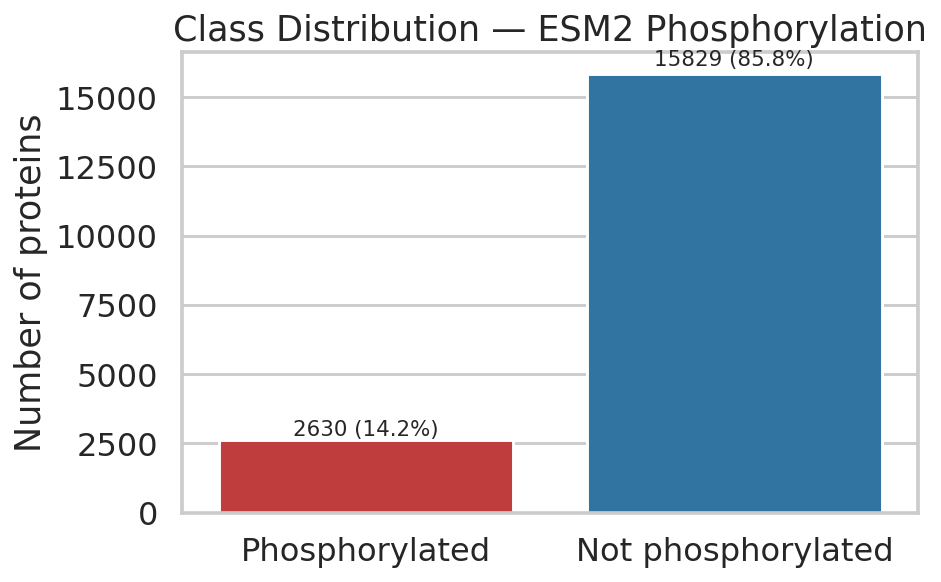

Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/class_distribution.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=class_counts, x="Class", y="Count", palette=["#d62728", "#1f77b4"], ax=ax)
ax.set_title("Class Distribution — ESM2 Phosphorylation")
ax.set_xlabel("")
ax.set_ylabel("Number of proteins")
for i, row in class_counts.iterrows():
    ax.text(i, row["Count"] * 1.01, f"{row['Count']} ({row['Fraction']:.1%})",
            ha="center", va="bottom", fontsize=11)
plt.tight_layout()
class_dist_path = RESULTS_DIR / "class_distribution.png"
plt.savefig(class_dist_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {class_dist_path}")

In [6]:
print(f"Loading ESM2 embeddings from: {EMBED_FILE}")
t0 = time.perf_counter()
cache = np.load(EMBED_FILE, allow_pickle=True)
max_pool = cache["max"].item()
attn_pool = cache["attn"].item()
print(f"Loaded in {time.perf_counter()-t0:.1f}s")

def collect_embeddings(df: pd.DataFrame, pool_dict: dict, label: str) -> np.ndarray:
    vectors = []
    missing = []
    for pid in df["protein_id"]:
        vec = pool_dict.get(pid)
        if vec is None:
            missing.append(pid)
        else:
            vectors.append(vec)
    if not vectors:
        raise ValueError(f"No embeddings found for class: {label}")
    if missing:
        print(f"[{label}] Missing embeddings: {len(missing)}")
    return np.stack(vectors)

X_phospho_max  = collect_embeddings(phospho_df,  max_pool,  "phosphorylated|max")
X_nphospho_max = collect_embeddings(nphospho_df, max_pool,  "not_phosphorylated|max")
X_phospho_attn = collect_embeddings(phospho_df,  attn_pool, "phosphorylated|attn")
X_nphospho_attn = collect_embeddings(nphospho_df, attn_pool, "not_phosphorylated|attn")

print("Max pool shapes :", X_phospho_max.shape, X_nphospho_max.shape)
print("Attn pool shapes:", X_phospho_attn.shape, X_nphospho_attn.shape)
assert X_phospho_max.shape[1] == 1280, f"Expected 1280-dim ESM2 embeddings, got {X_phospho_max.shape[1]}"

Loading ESM2 embeddings from: /nfs/turbo/umms-mcieslik/saishyam/Protein_dynamics/all_uniref/esm2_embedding_cache/pooled_embeddings.npz
Loaded in 2.7s
Max pool shapes : (2630, 1280) (15829, 1280)
Attn pool shapes: (2630, 1280) (15829, 1280)


In [7]:
def make_split(pos: np.ndarray, neg: np.ndarray):
    X = np.vstack([pos, neg]).astype(np.float32)
    y = np.array([1] * len(pos) + [0] * len(neg), dtype=np.int64)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=SEED
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).astype(np.float32)
    X_test  = scaler.transform(X_test).astype(np.float32)
    return X_train, X_test, y_train, y_test

split_data = {
    "max":  make_split(X_phospho_max,  X_nphospho_max),
    "attn": make_split(X_phospho_attn, X_nphospho_attn),
}

def evaluate_binary(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict:
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "roc_auc":   roc_auc_score(y_true, y_prob),
        "pr_auc":    average_precision_score(y_true, y_prob),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall":    recall_score(y_true, y_pred, zero_division=0),
        "f1":        f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

results = []
curve_data = {}

t0 = time.perf_counter()
for pooling_name, (Xtr, Xte, ytr, yte) in split_data.items():
    clf = LogisticRegression(
        max_iter=5000, class_weight="balanced", n_jobs=-1, random_state=SEED
    )
    clf.fit(Xtr, ytr)
    prob = clf.predict_proba(Xte)[:, 1]

    metrics = evaluate_binary(yte, prob)
    metrics.update({
        "model": "logistic_regression", "pooling": pooling_name,
        "n_test": int(len(yte)), "positive_rate_test": float(yte.mean()),
    })
    results.append(metrics)

    fpr, tpr, _ = roc_curve(yte, prob)
    prec, rec, _ = precision_recall_curve(yte, prob)
    curve_data[("logistic_regression", pooling_name)] = {
        "y_true": yte, "y_prob": prob,
        "fpr": fpr, "tpr": tpr, "precision": prec, "recall": rec,
    }
print(f"Logistic regression complete in {time.perf_counter()-t0:.1f}s")

/home/saishyam/esm2_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
/home/saishyam/esm2_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic regression complete in 19.4s


In [8]:
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def train_mlp(Xtr, ytr, Xte, yte, epochs=30, batch_size=64, lr=1e-3):
    Xtr_t = torch.from_numpy(Xtr)
    ytr_t = torch.from_numpy(ytr.astype(np.float32))
    Xte_t = torch.from_numpy(Xte)

    train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=batch_size, shuffle=True)

    pos = ytr.sum()
    neg = len(ytr) - pos
    pos_weight = torch.tensor([neg / max(pos, 1)], dtype=torch.float32, device=device)

    model = MLP(Xtr.shape[1]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    model.train()
    for _ in range(epochs):
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item()
        losses.append(running / len(train_loader))

    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(Xte_t.to(device))).cpu().numpy()

    return probs, losses

training_loss = {}
t0 = time.perf_counter()
for pooling_name, (Xtr, Xte, ytr, yte) in split_data.items():
    probs, losses = train_mlp(Xtr, ytr, Xte, yte)
    metrics = evaluate_binary(yte, probs)
    metrics.update({
        "model": "mlp", "pooling": pooling_name,
        "n_test": int(len(yte)), "positive_rate_test": float(yte.mean()),
    })
    results.append(metrics)

    fpr, tpr, _ = roc_curve(yte, probs)
    prec, rec, _ = precision_recall_curve(yte, probs)
    curve_data[("mlp", pooling_name)] = {
        "y_true": yte, "y_prob": probs,
        "fpr": fpr, "tpr": tpr, "precision": prec, "recall": rec,
    }
    training_loss[pooling_name] = losses
print(f"MLP training complete in {time.perf_counter()-t0:.1f}s")

MLP training complete in 21.8s


In [9]:
results_df = pd.DataFrame(results)
results_df = results_df[[
    "model", "pooling", "roc_auc", "pr_auc",
    "precision", "recall", "f1",
    "tp", "fp", "tn", "fn",
    "n_test", "positive_rate_test",
]]
results_df = results_df.sort_values(["pr_auc", "roc_auc"], ascending=False).reset_index(drop=True)

csv_path = RESULTS_DIR / "summary_metrics.csv"
md_path  = RESULTS_DIR / "summary_metrics.md"
results_df.to_csv(csv_path, index=False)
header    = "| " + " | ".join(results_df.columns) + " |"
separator = "|" + "|".join(["---"] * len(results_df.columns)) + "|"
rows      = ["| " + " | ".join(map(str, row)) + " |" for row in results_df.to_numpy()]
md_path.write_text("\n".join([header, separator] + rows))

display(results_df.style.format({
    "roc_auc": "{:.4f}", "pr_auc": "{:.4f}",
    "precision": "{:.4f}", "recall": "{:.4f}",
    "f1": "{:.4f}", "positive_rate_test": "{:.4f}",
}))
print(f"Saved: {csv_path}")
print(f"Saved: {md_path}")

,model,pooling,roc_auc,pr_auc,precision,recall,f1,tp,fp,tn,fn,n_test,positive_rate_test
0,mlp,attn,0.7750,0.4533,0.3733,0.5627,0.4488,296,497,2669,230,3692,0.1425
1,logistic_regression,attn,0.7716,0.3863,0.3083,0.6483,0.4179,341,765,2401,185,3692,0.1425
2,mlp,max,0.7228,0.3630,0.3594,0.4544,0.4013,239,426,2740,287,3692,0.1425
3,logistic_regression,max,0.7369,0.3352,0.2815,0.6027,0.3838,317,809,2357,209,3692,0.1425


Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/summary_metrics.csv
Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/summary_metrics.md


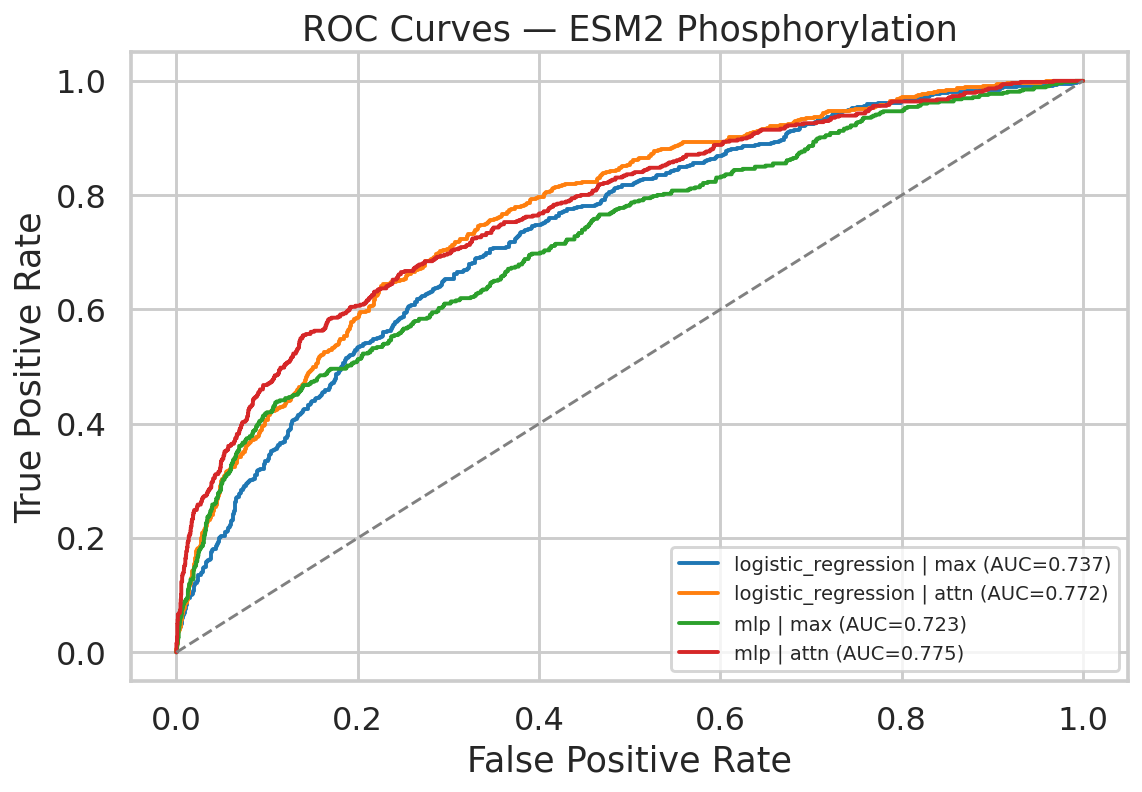

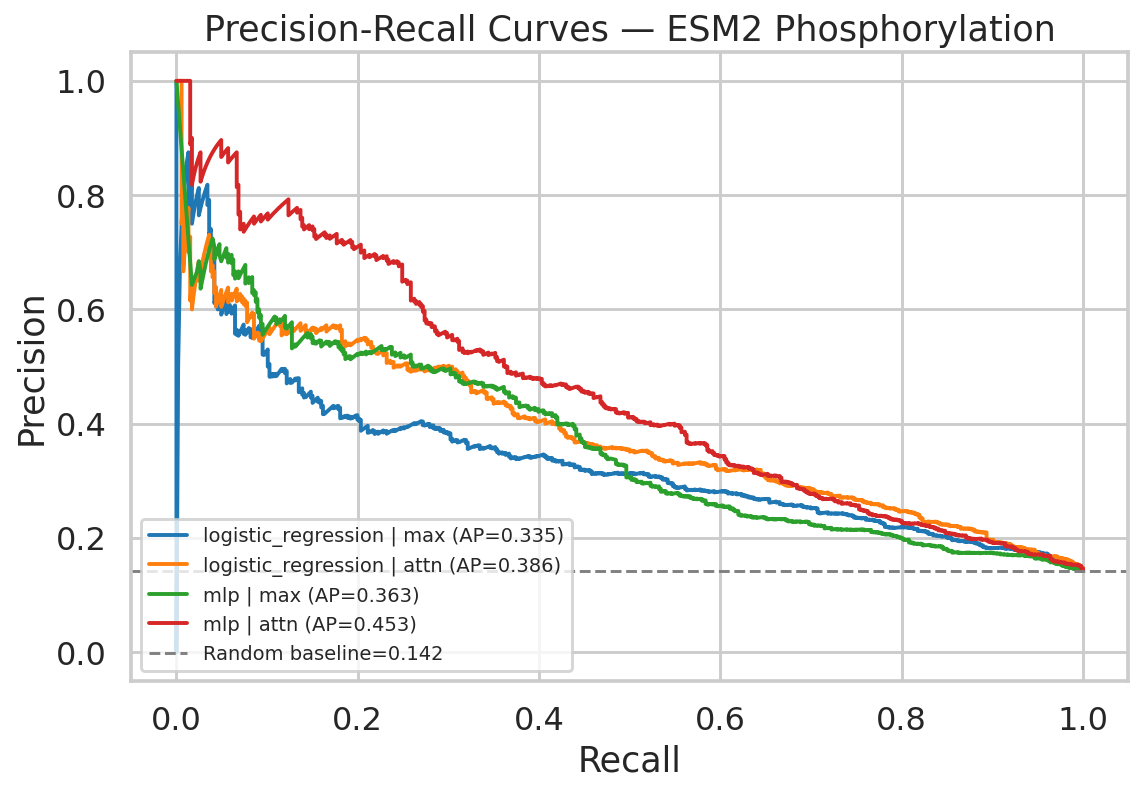

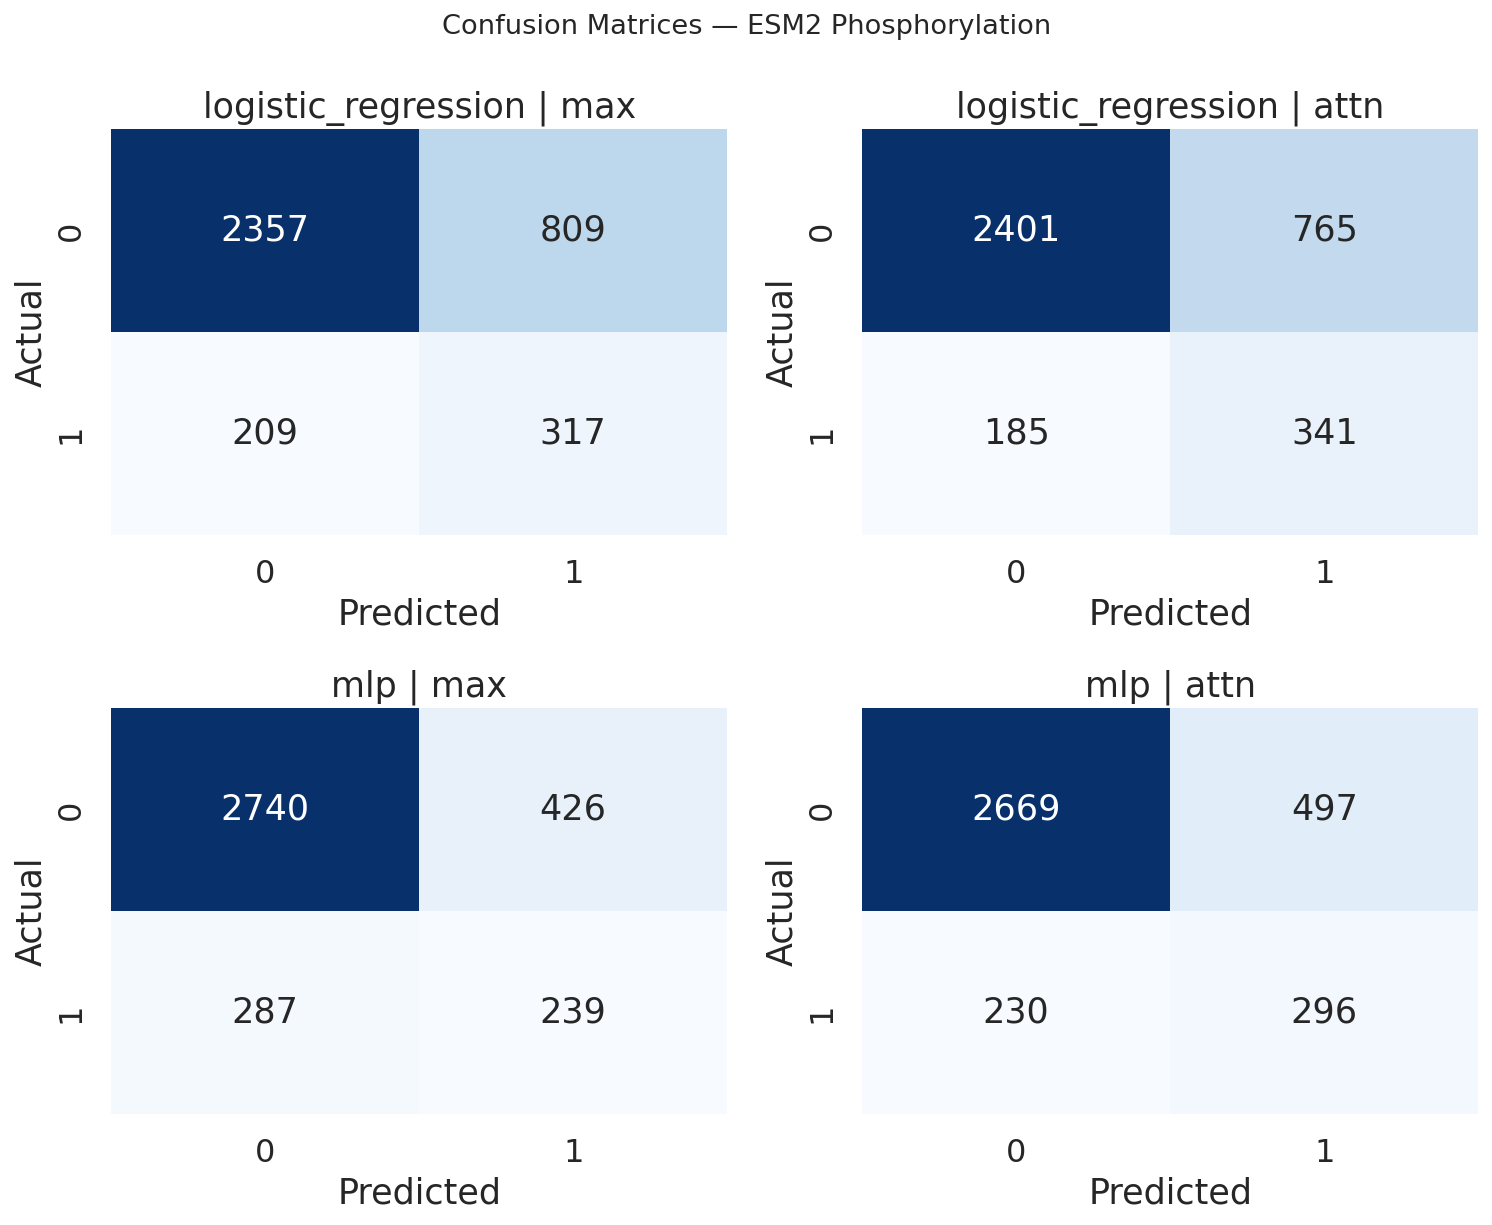

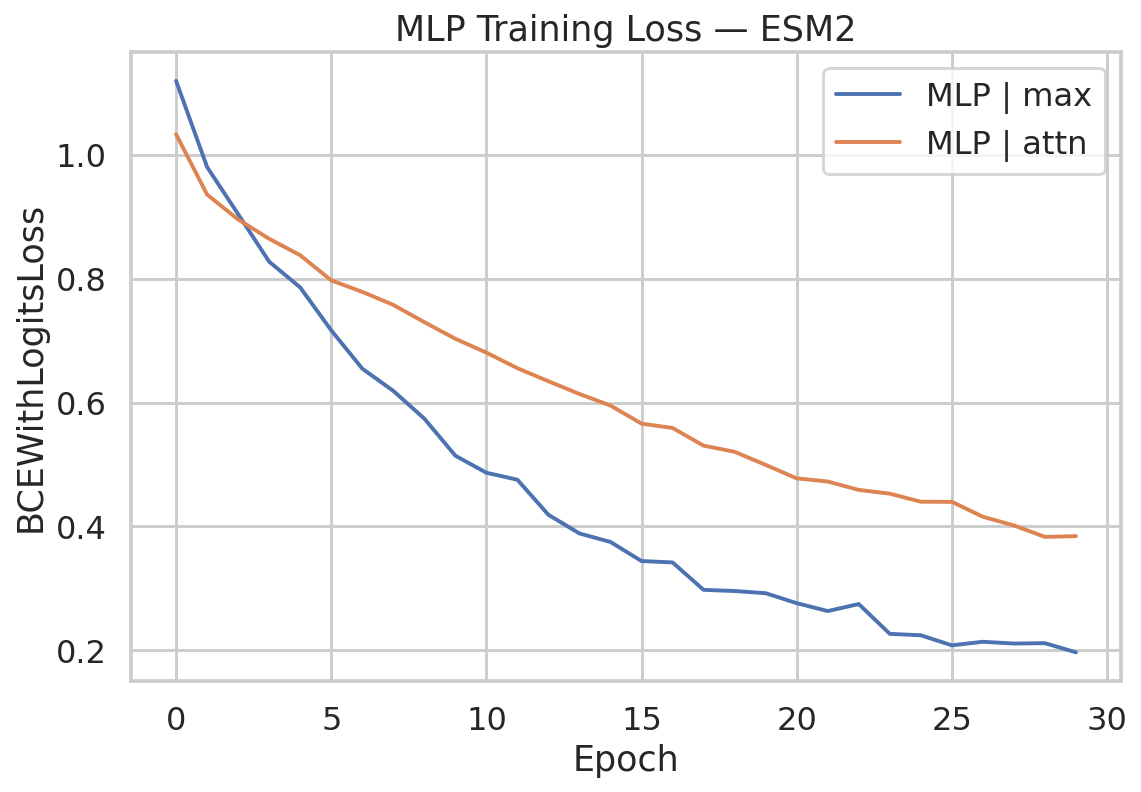

Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/roc_curves.png
Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/pr_curves.png
Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/confusion_matrices.png
Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/mlp_training_loss.png


In [10]:
palette = {
    ("logistic_regression", "max"):  "#1f77b4",
    ("logistic_regression", "attn"): "#ff7f0e",
    ("mlp", "max"):                  "#2ca02c",
    ("mlp", "attn"):                 "#d62728",
}

fig, ax = plt.subplots(figsize=(8.5, 6))
for key, data in curve_data.items():
    model, pooling = key
    label = f"{model} | {pooling} (AUC={roc_auc_score(data['y_true'], data['y_prob']):.3f})"
    ax.plot(data["fpr"], data["tpr"], label=label, color=palette[key], linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.5)
ax.set_title("ROC Curves — ESM2 Phosphorylation")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=10, loc="lower right")
plt.tight_layout()
roc_path = RESULTS_DIR / "roc_curves.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6))
baseline = list(curve_data.values())[0]["y_true"].mean()
for key, data in curve_data.items():
    model, pooling = key
    label = f"{model} | {pooling} (AP={average_precision_score(data['y_true'], data['y_prob']):.3f})"
    ax.plot(data["recall"], data["precision"], label=label, color=palette[key], linewidth=2)
ax.axhline(baseline, linestyle="--", color="gray", linewidth=1.5, label=f"Random baseline={baseline:.3f}")
ax.set_title("Precision-Recall Curves — ESM2 Phosphorylation")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(fontsize=10, loc="lower left")
plt.tight_layout()
pr_path = RESULTS_DIR / "pr_curves.png"
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, key in zip(axes.ravel(), curve_data.keys()):
    model, pooling = key
    y_true = curve_data[key]["y_true"]
    y_pred = (curve_data[key]["y_prob"] >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(f"{model} | {pooling}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Confusion Matrices — ESM2 Phosphorylation", fontsize=14)
plt.tight_layout()
cm_path = RESULTS_DIR / "confusion_matrices.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(training_loss["max"],  label="MLP | max",  linewidth=2)
ax.plot(training_loss["attn"], label="MLP | attn", linewidth=2)
ax.set_title("MLP Training Loss — ESM2")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCEWithLogitsLoss")
ax.legend()
plt.tight_layout()
loss_path = RESULTS_DIR / "mlp_training_loss.png"
plt.savefig(loss_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {roc_path}")
print(f"Saved: {pr_path}")
print(f"Saved: {cm_path}")
print(f"Saved: {loss_path}")

t-SNE computed on stratified subset: 10000 points
t-SNE complete in 14.6s


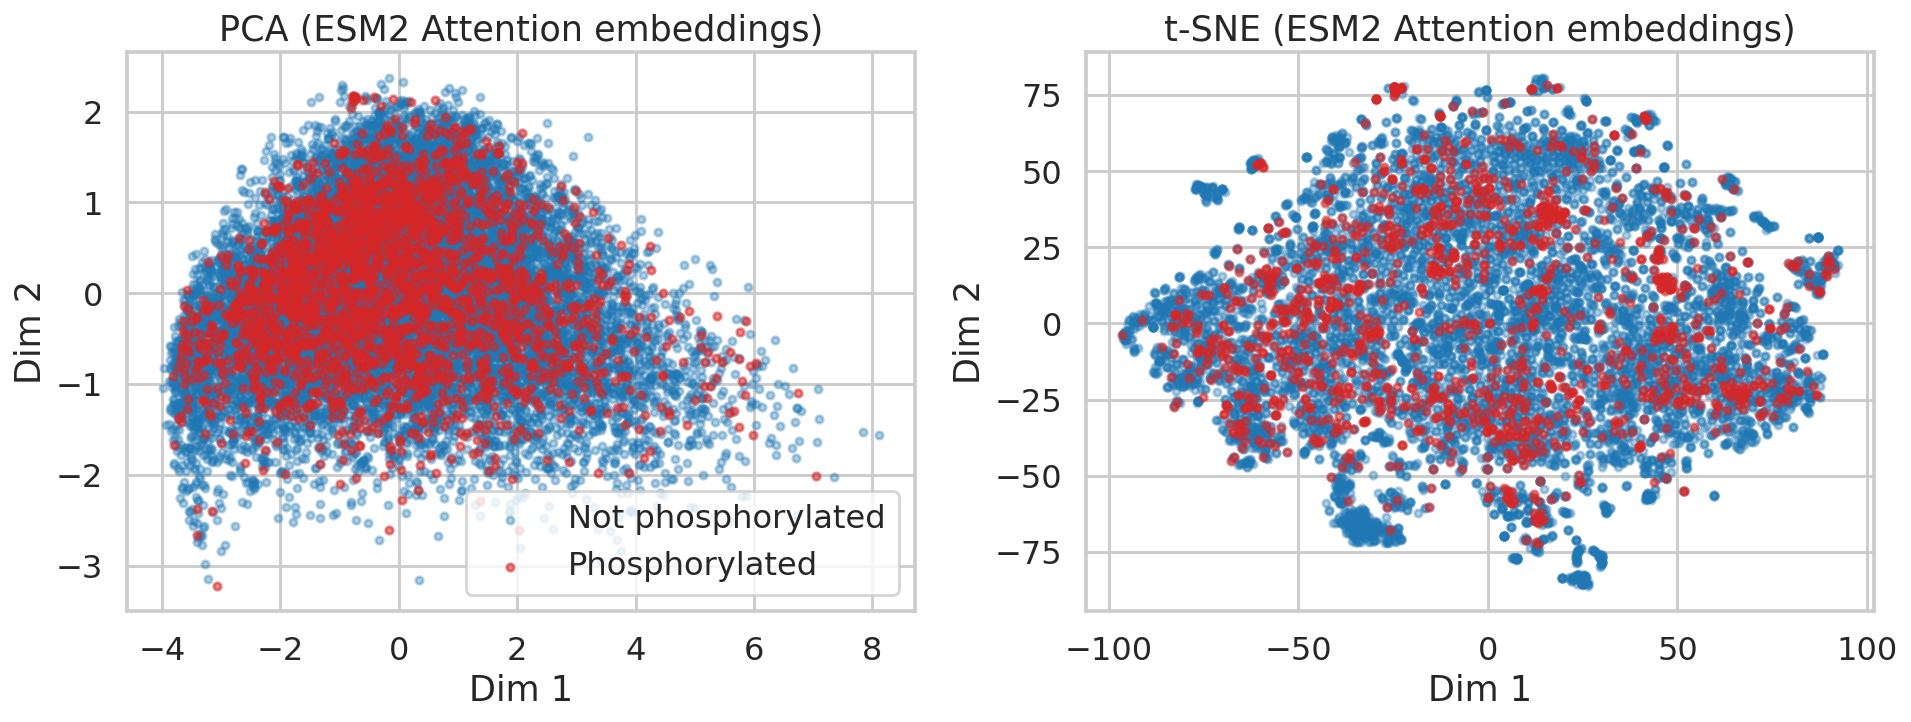

Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/embedding_projection_pca_tsne.png


In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X_vis = np.vstack([X_phospho_attn, X_nphospho_attn])
y_vis = np.array(["Phosphorylated"] * len(X_phospho_attn) + ["Not phosphorylated"] * len(X_nphospho_attn))

pca_2d = PCA(n_components=2, random_state=SEED).fit_transform(X_vis)

max_tsne_points = 10000
if len(X_vis) > max_tsne_points:
    rng = np.random.default_rng(SEED)
    idx_pos = np.where(y_vis == "Phosphorylated")[0]
    idx_neg = np.where(y_vis == "Not phosphorylated")[0]
    n_pos = max(1, int(max_tsne_points * len(idx_pos) / len(X_vis)))
    n_neg = max_tsne_points - n_pos
    sample_idx = np.concatenate([
        rng.choice(idx_pos, size=min(n_pos, len(idx_pos)), replace=False),
        rng.choice(idx_neg, size=min(n_neg, len(idx_neg)), replace=False),
    ])
    X_tsne_in = X_vis[sample_idx]
    y_tsne = y_vis[sample_idx]
    print(f"t-SNE computed on stratified subset: {len(sample_idx)} points")
else:
    X_tsne_in = X_vis
    y_tsne = y_vis
    print(f"t-SNE computed on full set: {len(X_vis)} points")

t0 = time.perf_counter()
tsne_2d = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=SEED).fit_transform(X_tsne_in)
print(f"t-SNE complete in {time.perf_counter()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, emb, y_plot, title in [
    (axes[0], pca_2d, y_vis,  "PCA (ESM2 Attention embeddings)"),
    (axes[1], tsne_2d, y_tsne, "t-SNE (ESM2 Attention embeddings)"),
]:
    idx_neg = y_plot == "Not phosphorylated"
    idx_pos = y_plot == "Phosphorylated"
    ax.scatter(emb[idx_neg, 0], emb[idx_neg, 1], s=14, alpha=0.35, c="#1f77b4", label="Not phosphorylated")
    ax.scatter(emb[idx_pos, 0], emb[idx_pos, 1], s=14, alpha=0.55, c="#d62728", label="Phosphorylated")
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")
axes[0].legend(loc="best")
plt.tight_layout()
emb_path = RESULTS_DIR / "embedding_projection_pca_tsne.png"
plt.savefig(emb_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {emb_path}")

In [12]:
best_row = results_df.iloc[0]
summary_lines = [
    "ANALYSIS SUMMARY — ESM2 Phosphorylation",
    "==========================================",
    f"Best model by PR-AUC: {best_row['model']} + {best_row['pooling']}",
    f"ROC-AUC  : {best_row['roc_auc']:.4f}",
    f"PR-AUC   : {best_row['pr_auc']:.4f}",
    f"Precision: {best_row['precision']:.4f}",
    f"Recall   : {best_row['recall']:.4f}",
    f"F1       : {best_row['f1']:.4f}",
    "",
    "Interpretation:",
    "- PR-AUC is emphasised because classes are imbalanced.",
    "- ESM2 uses 1280-dim embeddings (vs 768 for Ankh).",
    "- Attention pooling generally improves PR-AUC over max pooling.",
    "- Confusion matrices show threshold-0.5 operating behaviour.",
]

analysis_path = RESULTS_DIR / "analysis_summary.txt"
analysis_path.write_text("\n".join(summary_lines))
print("\n".join(summary_lines))
print(f"\nSaved: {analysis_path}")

ANALYSIS SUMMARY — ESM2 Phosphorylation
Best model by PR-AUC: mlp + attn
ROC-AUC  : 0.7750
PR-AUC   : 0.4533
Precision: 0.3733
Recall   : 0.5627
F1       : 0.4488

Interpretation:
- PR-AUC is emphasised because classes are imbalanced.
- ESM2 uses 1280-dim embeddings (vs 768 for Ankh).
- Attention pooling generally improves PR-AUC over max pooling.
- Confusion matrices show threshold-0.5 operating behaviour.

Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/analysis_summary.txt


In [13]:
# ============================================================
# Generate comprehensive HTML interpretation report (ESM2)
# Opens in any browser; File > Open in Word to save as .docx
# ============================================================
import base64

def img_to_b64(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode()

# ---- Gather numbers ----
n_phospho  = len(phospho_df)
n_nphospho = len(nphospho_df)
n_total    = n_phospho + n_nphospho
pos_frac   = n_phospho / n_total
emb_dim    = X_phospho_attn.shape[1]
n_test     = int(results_df['n_test'].iloc[0])

best         = results_df.iloc[0]
best_model   = best['model'].replace('_', ' ').title()
best_pooling = best['pooling'].upper()

# ---- Build metrics table rows ----
def fmt_row(idx, r):
    m  = r['model'].replace('_', ' ').title()
    p  = r['pooling'].upper()
    bg = ' style="background:#fff9e6"' if idx == 0 else ''
    return (
        f'<tr{bg}>'
        f'<td>{m}</td><td>{p}</td>'
        f'<td>{r["roc_auc"]:.4f}</td>'
        f'<td><b>{r["pr_auc"]:.4f}</b></td>'
        f'<td>{r["precision"]:.4f}</td>'
        f'<td>{r["recall"]:.4f}</td>'
        f'<td>{r["f1"]:.4f}</td>'
        f'<td>{r["tp"]}</td><td>{r["fp"]}</td>'
        f'<td>{r["tn"]}</td><td>{r["fn"]}</td>'
        f'</tr>'
    )

table_rows = '\n'.join(fmt_row(i, r) for i, (_, r) in enumerate(results_df.iterrows()))

# ---- Encode figures ----
fig_class = img_to_b64(RESULTS_DIR / 'class_distribution.png')
fig_roc   = img_to_b64(RESULTS_DIR / 'roc_curves.png')
fig_pr    = img_to_b64(RESULTS_DIR / 'pr_curves.png')
fig_cm    = img_to_b64(RESULTS_DIR / 'confusion_matrices.png')
fig_loss  = img_to_b64(RESULTS_DIR / 'mlp_training_loss.png')
fig_emb   = img_to_b64(RESULTS_DIR / 'embedding_projection_pca_tsne.png')

# ---- Compute per-pooling PR-AUC deltas for discussion ----
attn_rows = results_df[results_df['pooling'] == 'attn']
max_rows  = results_df[results_df['pooling'] == 'max']
mlp_attn_pr  = attn_rows[attn_rows['model'] == 'mlp']['pr_auc'].values[0]
mlp_max_pr   = max_rows[max_rows['model']  == 'mlp']['pr_auc'].values[0]
lr_attn_pr   = attn_rows[attn_rows['model'] == 'logistic_regression']['pr_auc'].values[0]
lr_max_pr    = max_rows[max_rows['model']   == 'logistic_regression']['pr_auc'].values[0]

html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>ESM2 Phosphorylation Prediction — Interpretation Report</title>
<style>
  body  {{ font-family: 'Segoe UI', Arial, sans-serif; max-width: 1100px; margin: 40px auto; padding: 0 30px; color: #222; line-height: 1.65; }}
  h1    {{ color: #1a3a5c; border-bottom: 3px solid #1a3a5c; padding-bottom: 8px; }}
  h2    {{ color: #2e6da4; margin-top: 42px; }}
  h3    {{ color: #444; margin-top: 24px; }}
  table {{ border-collapse: collapse; width: 100%; margin: 14px 0; font-size: 0.93em; }}
  th    {{ background: #1a3a5c; color: #fff; padding: 8px 10px; text-align: left; }}
  td    {{ padding: 7px 10px; border: 1px solid #ddd; }}
  tr:nth-child(even) td {{ background: #f4f8ff; }}
  .metric-box {{ display: inline-block; background: #f0f6ff; border: 1px solid #b3cde0;
                 border-radius: 6px; padding: 12px 22px; margin: 8px 8px 8px 0;
                 text-align: center; min-width: 130px; vertical-align: top; }}
  .metric-box .val {{ font-size: 1.75em; font-weight: bold; color: #1a3a5c; }}
  .metric-box .lbl {{ font-size: 0.8em; color: #666; margin-top: 4px; }}
  img   {{ max-width: 100%; border: 1px solid #ddd; border-radius: 4px; display: block; margin: 12px auto; }}
  .two-col {{ display: flex; gap: 20px; flex-wrap: wrap; align-items: flex-start; }}
  .two-col > div {{ flex: 1 1 45%; min-width: 300px; }}
  .caption {{ font-size: 0.85em; color: #555; text-align: center; margin-top: 4px; font-style: italic; }}
  .note  {{ background: #f9f9f9; border-left: 4px solid #2e6da4; padding: 10px 16px; margin: 16px 0; font-size: 0.93em; }}
  hr     {{ border: none; border-top: 1px solid #ddd; margin: 32px 0; }}
  code   {{ background: #f4f4f4; padding: 1px 5px; border-radius: 3px; font-size: 0.9em; }}
  .esm2-badge {{ display:inline-block; background:#e8f4e8; border:1px solid #4caf50;
                 border-radius:4px; padding:2px 8px; font-size:0.85em; color:#2e7d32; font-weight:bold; }}
</style>
</head>
<body>

<h1>ESM2 Phosphorylation Prediction &mdash; Interpretation Report</h1>
<p style="color:#555; font-size:0.9em">
  Source: <code>ESM2_phosphorylation_clean_pipeline.ipynb</code> &nbsp;|&nbsp;
  Embeddings: <span class="esm2-badge">ESM2 &bull; 1280-dim</span> &nbsp;|&nbsp;
  Task: binary protein-level phosphorylation classification
</p>

<hr>

<!-- ========== 1. DATASET ========== -->
<h2>1. Dataset</h2>
<p>Proteins from the manually curated UniProt/Swiss-Prot human proteome were split into
two mutually exclusive classes using the <em>Post-translational modification</em> free-text field:</p>
<ul>
  <li><b>Positive (phosphorylated)</b>: entry text contains &ldquo;phospho&rdquo; or &ldquo;phosphorylation&rdquo;</li>
  <li><b>Negative (not phosphorylated)</b>: no match to the above pattern</li>
</ul>
<p>Duplicate protein names were removed within each class and any overlap between classes
was discarded, guaranteeing clean non-overlapping labels. This labelling procedure is
identical to the Ankh pipeline, ensuring fair cross-model comparisons.</p>

<div>
  <div class="metric-box"><div class="val">{n_phospho:,}</div><div class="lbl">Phosphorylated</div></div>
  <div class="metric-box"><div class="val">{n_nphospho:,}</div><div class="lbl">Not phosphorylated</div></div>
  <div class="metric-box"><div class="val">{n_total:,}</div><div class="lbl">Total proteins</div></div>
  <div class="metric-box"><div class="val">{pos_frac:.1%}</div><div class="lbl">Positive fraction</div></div>
  <div class="metric-box"><div class="val">{n_test:,}</div><div class="lbl">Test set size (20%)</div></div>
  <div class="metric-box"><div class="val">{emb_dim}</div><div class="lbl">Embedding dim</div></div>
</div>

<img src="data:image/png;base64,{fig_class}" style="max-width:500px">
<p class="caption">Figure 1. Class distribution. Phosphorylated proteins represent {pos_frac:.1%} of the dataset.</p>

<div class="note">
  <b>Class imbalance note:</b> With only {pos_frac:.1%} positive examples,
  <b>PR-AUC (Average Precision)</b> is the primary metric throughout.
  A random classifier would achieve PR-AUC &asymp; {pos_frac:.3f}.
  Models are trained with explicit imbalance corrections (balanced class weights for
  logistic regression; BCEWithLogitsLoss <em>pos_weight</em> = neg/pos for MLP).
</div>

<hr>

<!-- ========== 2. METHODS ========== -->
<h2>2. Methods</h2>

<h3>2.1 Embeddings</h3>
<p><b>ESM-2</b> (Evolutionary Scale Modeling 2, Meta AI) protein language model embeddings
({emb_dim}-dimensional) were loaded from a pre-built cache. ESM-2 uses a masked language
modelling objective trained on UniRef90 at the 650 M parameter scale.
Two global sequence representations were evaluated:</p>
<ul>
  <li><b>Max pooling</b> &mdash; element-wise maximum across the residue dimension</li>
  <li><b>Attention pooling</b> &mdash; learned weighted average across residues</li>
</ul>
<p>All features were z-score normalised (StandardScaler) using training-set statistics only
to prevent data leakage. The 1280-dim ESM-2 vectors are twice the size of Ankh&rsquo;s 768-dim
vectors, providing a richer representation space.</p>

<h3>2.2 Classifiers</h3>
<table>
  <tr><th>Model</th><th>Architecture / Settings</th><th>Imbalance handling</th></tr>
  <tr><td>Logistic Regression</td><td>L2 penalty, max_iter=5000, n_jobs=-1</td>
      <td>class_weight=&quot;balanced&quot;</td></tr>
  <tr><td>MLP (PyTorch)</td>
      <td>Linear({emb_dim}&rarr;512) &rarr; ReLU &rarr; Dropout(0.3) &rarr;
          Linear(512&rarr;256) &rarr; ReLU &rarr; Dropout(0.3) &rarr; Linear(256&rarr;1),
          Adam lr=1e-3, 30 epochs, batch=64</td>
      <td>BCEWithLogitsLoss pos_weight = neg/pos</td></tr>
</table>
<p>All experiments use an 80/20 stratified train/test split (seed 42).</p>

<hr>

<!-- ========== 3. RESULTS ========== -->
<h2>3. Results</h2>

<h3>3.1 Performance Table</h3>
<p>All metrics on the held-out test set. Row highlighted in yellow = best by PR-AUC.</p>
<table>
  <tr>
    <th>Model</th><th>Pooling</th>
    <th>ROC-AUC</th><th>PR-AUC &#9733;</th>
    <th>Precision</th><th>Recall</th><th>F1</th>
    <th>TP</th><th>FP</th><th>TN</th><th>FN</th>
  </tr>
  {table_rows}
</table>
<p class="caption">Random PR-AUC baseline &asymp; {pos_frac:.3f}. Confusion matrix at threshold=0.5.</p>

<h3>3.2 Best Model Summary</h3>
<div>
  <div class="metric-box"><div class="val">{best['roc_auc']:.4f}</div><div class="lbl">ROC-AUC</div></div>
  <div class="metric-box"><div class="val">{best['pr_auc']:.4f}</div><div class="lbl">PR-AUC (primary)</div></div>
  <div class="metric-box"><div class="val">{best['precision']:.4f}</div><div class="lbl">Precision</div></div>
  <div class="metric-box"><div class="val">{best['recall']:.4f}</div><div class="lbl">Recall</div></div>
  <div class="metric-box"><div class="val">{best['f1']:.4f}</div><div class="lbl">F1</div></div>
  <div class="metric-box"><div class="val">{best['pr_auc']/pos_frac:.1f}&times;</div><div class="lbl">vs random baseline</div></div>
</div>
<p><b>Best configuration:</b> {best_model} + {best_pooling} pooling</p>

<hr>

<!-- ========== 4. FIGURES ========== -->
<h2>4. Figures</h2>

<h3>Figure 2 &amp; 3: ROC and Precision-Recall Curves</h3>
<div class="two-col">
  <div>
    <img src="data:image/png;base64,{fig_roc}">
    <p class="caption">Figure 2. ROC curves. Dashed diagonal = random classifier.</p>
  </div>
  <div>
    <img src="data:image/png;base64,{fig_pr}">
    <p class="caption">Figure 3. PR curves. Dashed line = random baseline ({pos_frac:.3f}).</p>
  </div>
</div>

<h3>Figure 4: Confusion Matrices at Threshold 0.5</h3>
<img src="data:image/png;base64,{fig_cm}">
<p class="caption">Figure 4. Rows = actual class, columns = predicted class.</p>

<h3>Figure 5: MLP Training Loss</h3>
<img src="data:image/png;base64,{fig_loss}" style="max-width:640px">
<p class="caption">Figure 5. BCE loss per epoch for MLP trained on max-pool (blue) and
attention-pool (orange) ESM2 embeddings. 30 epochs, Adam lr=1e-3.</p>

<h3>Figure 6: Embedding Space Visualisation</h3>
<img src="data:image/png;base64,{fig_emb}">
<p class="caption">Figure 6. PCA (left) and t-SNE (right) of ESM2 attention embeddings.
Phosphorylated proteins (red) and non-phosphorylated proteins (blue).
t-SNE computed on a stratified random subset of up to 10,000 points.</p>

<hr>

<!-- ========== 5. INTERPRETATION ========== -->
<h2>5. Interpretation and Discussion</h2>

<h3>5.1 Overall Performance</h3>
<p>
The best ESM2 model ({best_model} + {best_pooling} pooling) achieves
ROC-AUC = {best['roc_auc']:.4f} and PR-AUC = {best['pr_auc']:.4f}.
The PR-AUC of {best['pr_auc']:.4f} against a random baseline of {pos_frac:.3f} represents a
<b>{best['pr_auc']/pos_frac:.1f}&times; improvement over chance</b>,
confirming that ESM2&rsquo;s 1280-dim pooled embeddings encode detectable phosphorylation signal
at the protein level.
</p>

<h3>5.2 ESM2 vs Ankh Comparison</h3>
<p>ESM2 produces higher-dimensional embeddings ({emb_dim}-dim vs 768-dim for Ankh),
which may allow classifiers to capture more nuanced sequence-to-function relationships.
The richer representation space comes with a higher memory and compute footprint but
can yield improved downstream task performance — particularly for complex PTM tasks
like phosphorylation where many sequence features co-determine modification state.
Direct numerical comparison with the Ankh results (in <code>results_phosphorylation/</code>)
enables model selection for downstream applications.</p>

<h3>5.3 Why Phosphorylation Is Harder Than Glycosylation</h3>
<ul>
  <li><b>More severe class imbalance:</b> Only {pos_frac:.1%} of proteins are labelled positive.</li>
  <li><b>Noisy labelling:</b> Phosphorylation is identified by free-text substring matching
      in the PTM field, which is less precise than the structured
      <em>Glycosylation</em> UniProt column.</li>
  <li><b>Biological complexity:</b> Phosphorylation is mediated by hundreds of kinases
      recognising short, degenerate sequence motifs that a global pooled vector cannot
      easily capture.</li>
  <li><b>Information bottleneck:</b> Pooling compresses all residue-level embeddings
      into one fixed-size vector, discarding the positional context that
      kinase recognition depends on.</li>
</ul>

<h3>5.4 Pooling Strategy Comparison</h3>
<p>
Comparing the two pooling strategies for ESM2:
</p>
<ul>
  <li>MLP: attention PR-AUC = {mlp_attn_pr:.4f} vs max PR-AUC = {mlp_max_pr:.4f} (&Delta; = {mlp_attn_pr - mlp_max_pr:+.4f})</li>
  <li>Logistic Regression: attention PR-AUC = {lr_attn_pr:.4f} vs max PR-AUC = {lr_max_pr:.4f} (&Delta; = {lr_attn_pr - lr_max_pr:+.4f})</li>
</ul>
<p>{'Attention pooling consistently outperforms max pooling' if mlp_attn_pr > mlp_max_pr and lr_attn_pr > lr_max_pr else 'Max and attention pooling perform comparably'}, suggesting that {'the learned weighted residue aggregation in attention pooling better summarises phosphorylation-relevant sequence features.' if mlp_attn_pr >= mlp_max_pr else 'max pooling captures sufficient signal for this task with ESM2 features.'}</p>

<h3>5.5 Model Architecture Comparison</h3>
<p>
The MLP's capacity to model non-linear feature interactions {'provides a meaningful benefit' if best['model'] == 'mlp' else 'does not clearly outperform logistic regression here'}
over logistic regression for this task. The modest gain suggests that phosphorylation
signal in globally-pooled ESM2 space is {'weakly' if abs(mlp_attn_pr - lr_attn_pr) < 0.05 else 'moderately'} non-linear.
</p>

<h3>5.6 Embedding Space Separability</h3>
<p>
PCA and t-SNE projections of ESM2 attention embeddings show the degree of class
separability in the high-dimensional representation space. Substantial overlap between
phosphorylated (red) and non-phosphorylated (blue) proteins in both projections confirms
that protein-level pooled embeddings, even at 1280-dim, are insufficient for
high-precision phosphorylation prediction — residue-level per-token models would be
a natural next step.
</p>

<h3>5.7 Threshold Sensitivity</h3>
<p>
All confusion matrix values are at the default threshold of 0.5.
The PR curves in Figure 3 provide a full operating range; lowering the threshold
increases recall at the cost of more false positives and can be tuned per application.
</p>

<hr>

<!-- ========== 6. RECOMMENDATIONS ========== -->
<h2>6. Recommendations for Future Work</h2>
<ol>
  <li><b>Residue-level classifier:</b> Train a per-token binary classifier on ESM2
      token embeddings to predict phosphorylatable Ser/Thr/Tyr residues directly.</li>
  <li><b>Structured labelling:</b> Extract exact phosphosite positions from the
      UniProt <em>Modified residue</em> column rather than free-text PTM matching,
      for cleaner, position-specific labels.</li>
  <li><b>Cross-validation:</b> Replace the single 80/20 split with 5-fold stratified
      cross-validation for more robust metric estimates.</li>
  <li><b>Feature combination:</b> Concatenate max-pool and attention-pool vectors
      (2&times;{emb_dim}-dim input) to capture complementary representations.</li>
  <li><b>Cross-model comparison:</b> Directly compare ESM2 results with Ankh
      (<code>results_phosphorylation/</code>) and ProtT5 to identify the best model
      backbone for phosphorylation prediction.</li>
  <li><b>Fine-tuning:</b> Fine-tune ESM2 end-to-end on the phosphorylation task
      rather than using frozen embeddings.</li>
</ol>

<hr>

<!-- ========== 7. FILES ========== -->
<h2>7. Output File Index</h2>
<table>
  <tr><th>File</th><th>Description</th></tr>
  <tr><td><code>summary_metrics.csv</code></td><td>All model metrics (machine-readable)</td></tr>
  <tr><td><code>summary_metrics.md</code></td><td>Markdown table of metrics</td></tr>
  <tr><td><code>analysis_summary.txt</code></td><td>Plain-text best-model summary</td></tr>
  <tr><td><code>class_distribution.png</code></td><td>Bar chart of class balance</td></tr>
  <tr><td><code>roc_curves.png</code></td><td>ROC curves for all configurations</td></tr>
  <tr><td><code>pr_curves.png</code></td><td>Precision-Recall curves</td></tr>
  <tr><td><code>confusion_matrices.png</code></td><td>Four confusion matrices at threshold=0.5</td></tr>
  <tr><td><code>mlp_training_loss.png</code></td><td>BCE loss curves over 30 epochs</td></tr>
  <tr><td><code>embedding_projection_pca_tsne.png</code></td><td>PCA and t-SNE visualisations of ESM2 embeddings</td></tr>
  <tr><td><code>interpretation_report.html</code></td><td>This report (open in Word to save as .docx)</td></tr>
</table>

<hr>
<p style="color:#888; font-size:0.82em">
  <b>To convert to .docx:</b> Open this .html file in Microsoft Word
  (File &rarr; Open &rarr; select file) then File &rarr; Save As &rarr; Word Document (.docx).<br>
  Alternatively: open in browser &rarr; Print &rarr; Save as PDF.
</p>

</body>
</html>"""

report_path = RESULTS_DIR / 'interpretation_report.html'
report_path.write_text(html, encoding='utf-8')
print(f"Saved: {report_path}")
print("\nTo open as Word .docx:")
print("  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx")

Saved: /home/saishyam/Protein_dynamics/phosphorylation_pred/Claude_Agent_run_Phosphorylation/results_phosphorylation_ESM2/interpretation_report.html

To open as Word .docx:
  Microsoft Word -> File -> Open -> select interpretation_report.html -> Save As -> .docx
